In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load journal data
journal = pd.read_parquet("data/journal_daily.parquet")
journal["date"] = pd.to_datetime(journal["date"])
journal = journal.sort_values("date").reset_index(drop=True)

# Optional: inspect columns
print(journal.columns.tolist())
journal.head()

['date', 'gross_portfolio_return', 'trading_cost', 'net_portfolio_return', 'turnover', 'portfolio_value', 'cumulative_return', 'drawdown', 'benchmark_return', 'excess_return']


,date,gross_portfolio_return,trading_cost,net_portfolio_return,turnover,portfolio_value,cumulative_return,drawdown,benchmark_return,excess_return
0,2021-03-08,0.0,0.0,0.0,0.0,1000000.0,0.0,0.0,0.000000,0.000000
1,2021-03-09,0.0,0.0,0.0,0.0,1000000.0,0.0,0.0,0.001875,-0.001875
2,2021-03-10,0.0,0.0,0.0,0.0,1000000.0,0.0,0.0,0.007060,-0.007060
3,2021-03-12,0.0,0.0,0.0,0.0,1000000.0,0.0,0.0,-0.009070,0.009070
4,2021-03-15,0.0,0.0,0.0,0.0,1000000.0,0.0,0.0,-0.004389,0.004389


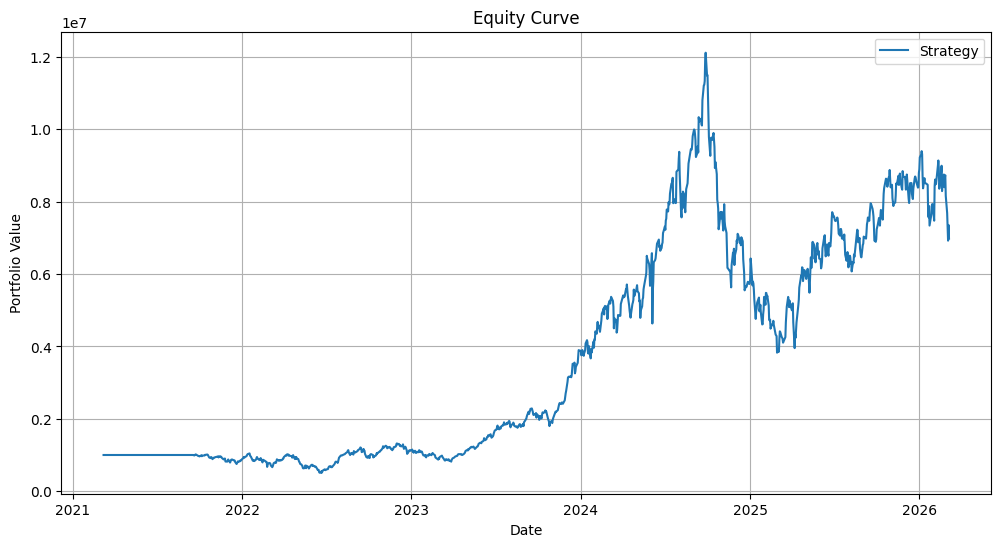

In [2]:
# Equity curve
plt.figure(figsize=(12, 6))
plt.plot(journal["date"], journal["portfolio_value"], label="Strategy")
plt.title("Equity Curve")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

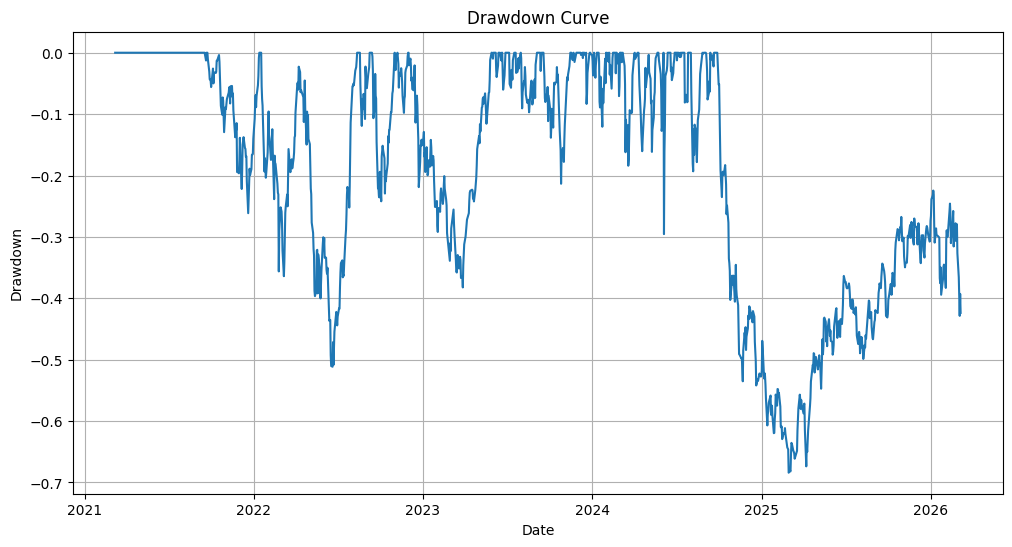

In [3]:
# Drawdown curve
plt.figure(figsize=(12, 6))
plt.plot(journal["date"], journal["drawdown"])
plt.title("Drawdown Curve")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()

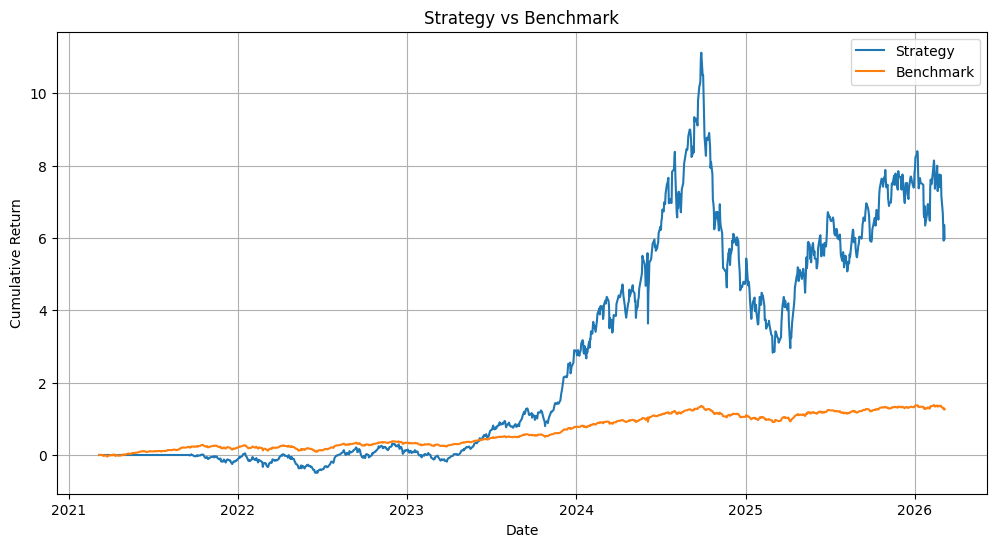

In [4]:
# Strategy vs benchmark cumulative return
if "benchmark_return" in journal.columns:
    journal["benchmark_cumulative_return"] = (1.0 + journal["benchmark_return"].fillna(0.0)).cumprod() - 1.0

    plt.figure(figsize=(12, 6))
    plt.plot(journal["date"], journal["cumulative_return"], label="Strategy")
    plt.plot(journal["date"], journal["benchmark_cumulative_return"], label="Benchmark")
    plt.title("Strategy vs Benchmark")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.legend()
    plt.grid(True)
    plt.show()

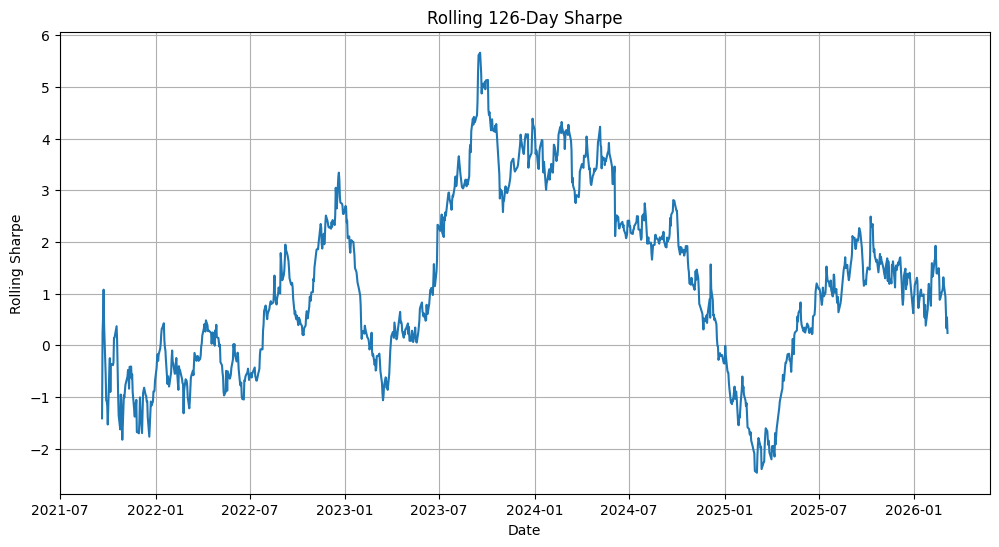

In [5]:
# Rolling Sharpe (126 trading days ~= 6 months)
rolling_window = 126

rolling_mean = journal["net_portfolio_return"].rolling(rolling_window).mean()
rolling_std = journal["net_portfolio_return"].rolling(rolling_window).std()
journal["rolling_sharpe_126d"] = (rolling_mean / rolling_std) * (252 ** 0.5)

plt.figure(figsize=(12, 6))
plt.plot(journal["date"], journal["rolling_sharpe_126d"])
plt.title("Rolling 126-Day Sharpe")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe")
plt.grid(True)
plt.show()

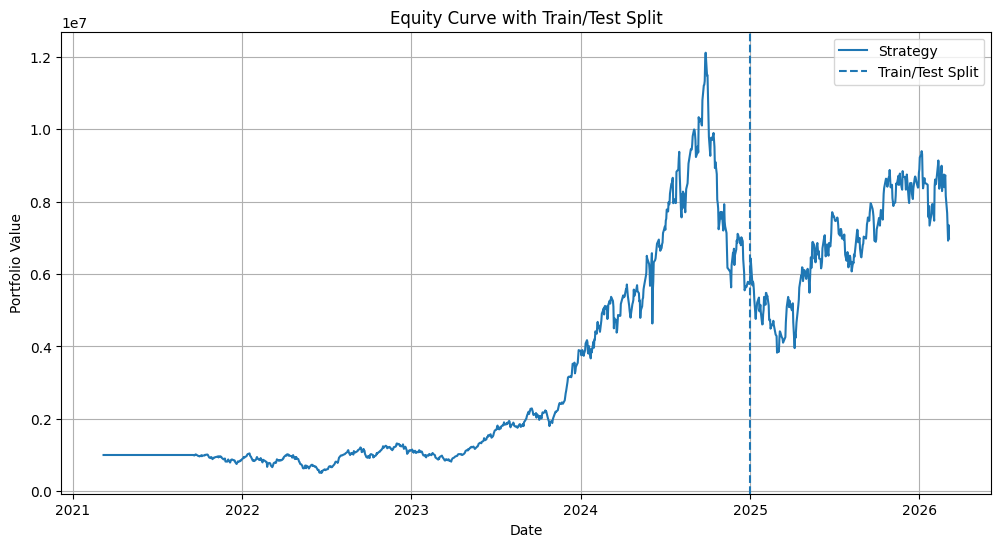

In [6]:
# Train vs test vertical split marker
split_date = pd.Timestamp("2025-01-01")

plt.figure(figsize=(12, 6))
plt.plot(journal["date"], journal["portfolio_value"], label="Strategy")
plt.axvline(split_date, linestyle="--", label="Train/Test Split")
plt.title("Equity Curve with Train/Test Split")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

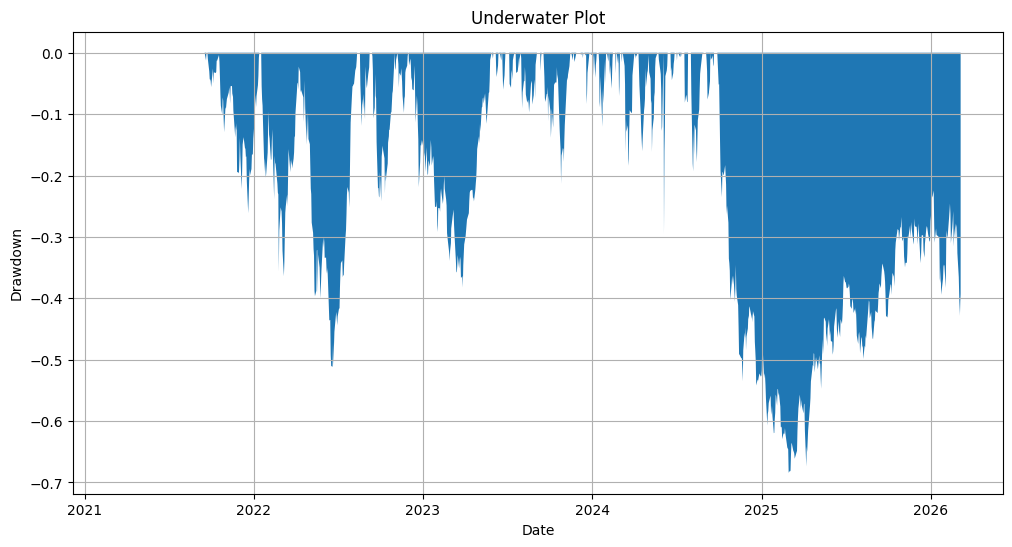

In [7]:
# Underwater plot (same drawdown, but visually clearer)
plt.figure(figsize=(12, 6))
plt.fill_between(journal["date"], journal["drawdown"], 0)
plt.title("Underwater Plot")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()